## Extraccion de datos de CA para fines de Orden Interno y Seguridad Pública

In [1]:
# INSTALACION DE PAQUETES Y DEPENDENCIAS
%pip install pandas
%pip install lxml

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\edwar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\edwar\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Enlaces
* Enlace para limpiar:https://apps5.mineco.gob.pe/transparencia/Navegador/Navegar_7.aspx?_tgt=xls&_uhc=yes&0=&30=0030&21=&y=2025&cpage=1&psize=400
* Enlace limpiado:    https://apps5.mineco.gob.pe/transparencia/Navegador/Navegar_7.aspx?0=&30=0030&21=&y=2025

In [ ]:
import pandas as pd
url = "https://apps5.mineco.gob.pe/transparencia/Navegador/Navegar_7.aspx?0=&30=0030&21=&y=2025"  # URL asociada a la información de interés
ls = pd.read_html(url, encoding="utf-8") # Lee el enlace y guarda la información asociada
print(f"Objeto cargado usando: {url}")


Objeto cargado usando: https://apps5.mineco.gob.pe/transparencia/Navegador/Navegar_7.aspx?0=&30=0030&21=&y=2025


**INDEXACION**


### Cuadro 2: Correspondencia de columnas del Dataframe con columnas de CA
| Nº | Nombre/Concepto                     |
|----|-------------------------------------|
| 1  | Nombre/Concepto                     |
| 2  | PIA (Presupuesto Inicial de Apertura)       |
| 3  | PIM (Presupuesto Institucional Modificado) |
| 4  | Certificación                       |
| 5  | Compromiso Anual                    |
| 6  | Atención de Compromiso Mensual     |
| 7  | Devengado                          |
| 8  | Girado                             |
| 9  | Avance (%)                         |

* Tip 1: Para encontrar el número de tabla debe examinarse visualmente la lista. Sin embargo, en la mayoría de casos, la tabla con la información principal normalmente se obtiene indexando la lista con 7, 8 o 9. Esto depende del nivel de profundidad de la búsqueda en CA.

In [5]:
## DISPLAY DE LOS ULTIMOS ELEMENTOS DE LA LISTA
df = ls[9] # Selecciona la tabla 9 de la lista
display(df.tail())

,0,1,2,3,4,5,6,7,8,9
20,NaN,21: PUNO,160055495,191025041,189542143,187040820,186126556,185983089,185926235,97.4
21,NaN,22: SAN MARTIN,127446676,152357781,150398538,149578319,147580466,146851730,146829024,96.4
22,NaN,23: TACNA,89560898,131901695,130792197,130115168,129896752,129245288,129050150,98.0
23,NaN,24: TUMBES,50798122,80868417,78766289,78354584,78125167,77835877,77740845,96.3
24,NaN,25: UCAYALI,63353277,90417064,88767054,87977035,87692651,87511269,87506674,96.8


In [6]:
## SELECCION DE PIA, PIM, DEVENGADO Y AVANCE
df = df.iloc[:,[1,2,3,7,9]] # Selecciona el Pliego y el Devengado
df.columns = ["Pliego","PIA","PIM", "Devengado","Avance"] # Renombra las columnas seleccionadas
display(df.tail())

,Pliego,PIA,PIM,Devengado,Avance
20,21: PUNO,160055495,191025041,185983089,97.4
21,22: SAN MARTIN,127446676,152357781,146851730,96.4
22,23: TACNA,89560898,131901695,129245288,98.0
23,24: TUMBES,50798122,80868417,77835877,96.3
24,25: UCAYALI,63353277,90417064,87511269,96.8


### **Extraccion de datos anuales  (PANEL DE DATOS REGIONALES)** 

In [17]:
%%time
import pandas as pd
import os  # Librería para manejar rutas del sistema

# Haciendo bucle
bd_oi = pd.DataFrame()

for i in range(2015, 2026):
    url = f"https://apps5.mineco.gob.pe/transparencia/Navegador/Navegar_7.aspx?0=&30=0030&21=&y={i}"
    # Lee el enlace y selecciona las columnas de interés
    df = pd.read_html(url, encoding="utf-8")[9].iloc[:,[1,3,7,9]] 
    # Renombra las columnas
    df.columns = ["Región", "Presupuesto", "Devengado", "Ejecución"] 
    df["Año"] = i
    print(f"Descarga de: {url}")
    bd_oi = pd.concat([bd_oi, df])

bd_oi.reset_index(drop=True, inplace=True)

# --- CONFIGURACIÓN DE DESCARGA ---
nombre_archivo = "reporte_ejecucion_mef_2015_2025.xlsx"
bd_oi.to_excel(nombre_archivo, index=False)

# Línea que indica la ruta exacta de descarga
ruta_completa = os.path.abspath(nombre_archivo)
print(f"\n✅ ¡Éxito! El archivo se ha descargado en: {ruta_completa}")
# ---------------------------------

display(bd_oi)
print("Tiempo de ejecución:")


Descarga de: https://apps5.mineco.gob.pe/transparencia/Navegador/Navegar_7.aspx?0=&30=0030&21=&y=2015
Descarga de: https://apps5.mineco.gob.pe/transparencia/Navegador/Navegar_7.aspx?0=&30=0030&21=&y=2016
Descarga de: https://apps5.mineco.gob.pe/transparencia/Navegador/Navegar_7.aspx?0=&30=0030&21=&y=2017
Descarga de: https://apps5.mineco.gob.pe/transparencia/Navegador/Navegar_7.aspx?0=&30=0030&21=&y=2018
Descarga de: https://apps5.mineco.gob.pe/transparencia/Navegador/Navegar_7.aspx?0=&30=0030&21=&y=2019
Descarga de: https://apps5.mineco.gob.pe/transparencia/Navegador/Navegar_7.aspx?0=&30=0030&21=&y=2020
Descarga de: https://apps5.mineco.gob.pe/transparencia/Navegador/Navegar_7.aspx?0=&30=0030&21=&y=2021
Descarga de: https://apps5.mineco.gob.pe/transparencia/Navegador/Navegar_7.aspx?0=&30=0030&21=&y=2022
Descarga de: https://apps5.mineco.gob.pe/transparencia/Navegador/Navegar_7.aspx?0=&30=0030&21=&y=2023
Descarga de: https://apps5.mineco.gob.pe/transparencia/Navegador/Navegar_7.aspx?0=

,Región,Presupuesto,Devengado,Ejecución,Año
0,01: AMAZONAS,68080148,67238522,98.8,2015
1,02: ANCASH,160007898,147577696,92.2,2015
2,03: APURIMAC,70625440,61707679,87.4,2015
3,04: AREQUIPA,384432155,366796062,95.4,2015
4,05: AYACUCHO,61497091,53233910,86.6,2015
...,...,...,...,...,...
270,21: PUNO,191025041,185983089,97.4,2025
271,22: SAN MARTIN,152357781,146851730,96.4,2025
272,23: TACNA,131901695,129245288,98.0,2025
273,24: TUMBES,80868417,77835877,96.3,2025


Tiempo de ejecución:
CPU times: total: 109 ms
Wall time: 48.7 s


## **Gráficos**

Gráfico generado exitosamente en: C:\Users\edwar\OneDrive\Documents\evolucion_ejecucion_multiformato.png


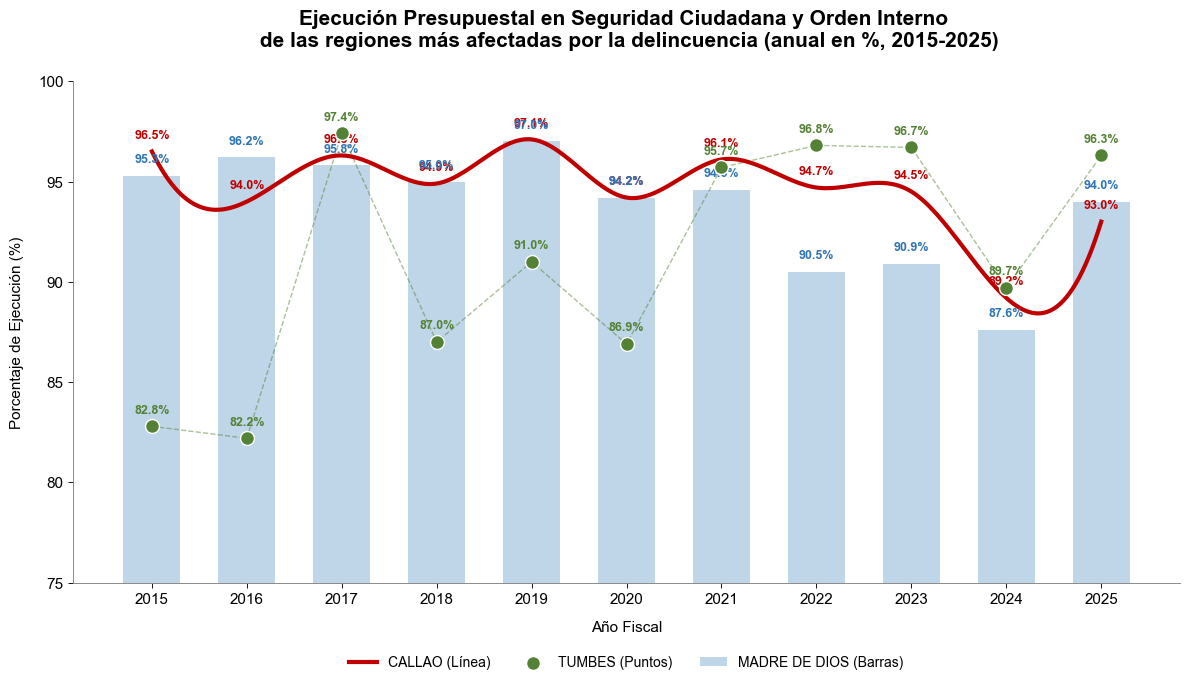

In [27]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.interpolate import make_interp_spline
import numpy as np
import os

# 1. Preparar datos y ruta ================================================
ruta_excel = r"C:\Users\edwar\OneDrive\Documents\reporte_ejecucion_mef_2015_2025.xlsx"

if os.path.exists(ruta_excel):
    # Cargamos el archivo Excel
    df_full = pd.read_excel(ruta_excel)
else:
    print(f"Error: No se encontró el archivo en {ruta_excel}")
    exit()

# Nombres exactos y configuración de estilos
regiones_config = {
    "CALLAO": {"nombre": "07: PROVINCIA CONSTITUCIONAL DEL CALLAO", "color": "#C00000", "estilo": "suave"},
    "MADRE DE DIOS": {"nombre": "17: MADRE DE DIOS", "color": "#2E75B6", "estilo": "barra"},
    "TUMBES": {"nombre": "24: TUMBES", "color": "#548235", "estilo": "puntos"}
}

# Configuración estética
mpl.rcParams['font.family'] = 'Arial'
fig, ax = plt.subplots(figsize=(12, 7))

# Estilo de ejes minimalista
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for s in ["left", "bottom"]:
    ax.spines[s].set_color("#808080")
    ax.spines[s].set_linewidth(0.64)
ax.tick_params(axis="both", width=0.64, labelsize=11)

# 2. Graficar cada región con su estilo específico =========================
for label, config in regiones_config.items():
    # Filtrar, limpiar nulos y ordenar por año
    df_reg = df_full[df_full["Región"] == config["nombre"]].dropna(subset=["Ejecución"]).sort_values("Año")
    
    x = df_reg["Año"].values
    y = df_reg["Ejecución"].values

    if config["estilo"] == "suave":
        # Curva suavizada (Spline)
        x_suave = np.linspace(x.min(), x.max(), 300)
        y_suave = make_interp_spline(x, y, k=3)(x_suave)
        ax.plot(x_suave, y_suave, color=config["color"], lw=3, label=f"{label} (Línea)", zorder=3)
    
    elif config["estilo"] == "barra":
        # Gráfico de barras con transparencia
        ax.bar(x, y, color=config["color"], alpha=0.3, width=0.6, label=f"{label} (Barras)", zorder=1)
    
    elif config["estilo"] == "puntos":
        # Solo puntos destacados
        ax.scatter(x, y, color=config["color"], s=100, label=f"{label} (Puntos)", edgecolors='white', zorder=4)
        # Línea punteada muy fina para conectar los puntos
        ax.plot(x, y, color=config["color"], lw=1, linestyle='--', alpha=0.5, zorder=2)

    # Etiquetas de datos (Porcentajes) - Corregido el comentario faltante
    for xi, yi in zip(x, y):
        ax.text(xi, yi + 0.5, f"{yi:.1f}%", ha="center", va="bottom", 
                fontsize=9, color=config["color"], fontweight='bold')

# 3. Reescala del eje Y y ajustes finales =================================
ax.set_ylim(75, 100) # Subimos un poco el tope para que las etiquetas no se corten
ax.set_xticks(df_full["Año"].unique()) 

plt.title("Ejecución Presupuestal en Seguridad Ciudadana y Orden Interno \n de las regiones más afectadas por la delincuencia (anual en %, 2015-2025)", 
          fontsize=15, fontweight='bold', pad=25)
ax.set_ylabel("Porcentaje de Ejecución (%)", fontsize=11, labelpad=10)
ax.set_xlabel("Año Fiscal", fontsize=11, labelpad=10)

# Leyenda
ax.legend(fontsize=10, frameon=False, loc='upper center', 
          bbox_to_anchor=(0.5, -0.12), ncol=3)

plt.tight_layout()

# Guardar imagen
output_img = os.path.join(os.path.dirname(ruta_excel), "evolucion_ejecucion_multiformato.png")
plt.savefig(output_img, dpi=300, bbox_inches='tight')

print(f"Gráfico generado exitosamente en: {output_img}")
plt.show()

Gráfico de CALLAO guardado en: C:\Users\edwar\OneDrive\Documents\ejecucion_callao.png


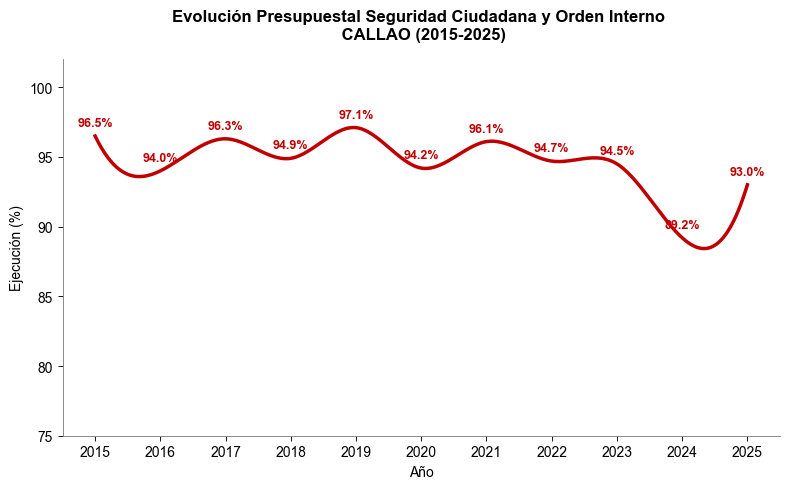

Gráfico de MADRE DE DIOS guardado en: C:\Users\edwar\OneDrive\Documents\ejecucion_madre_de_dios.png


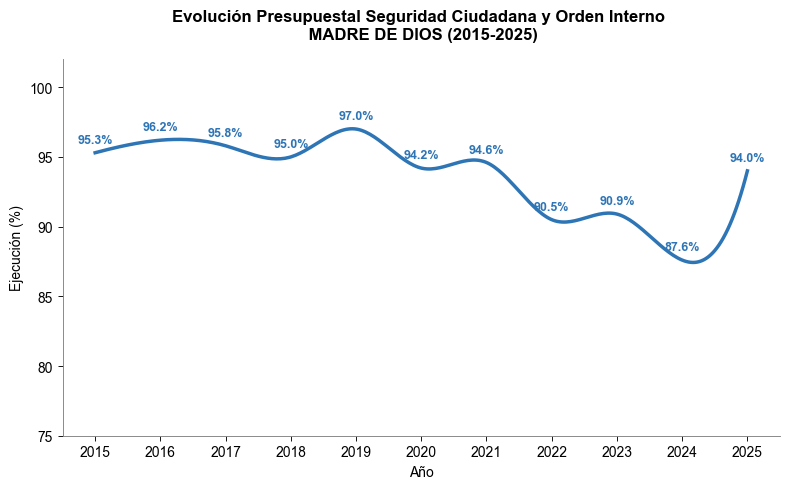

Gráfico de TUMBES guardado en: C:\Users\edwar\OneDrive\Documents\ejecucion_tumbes.png


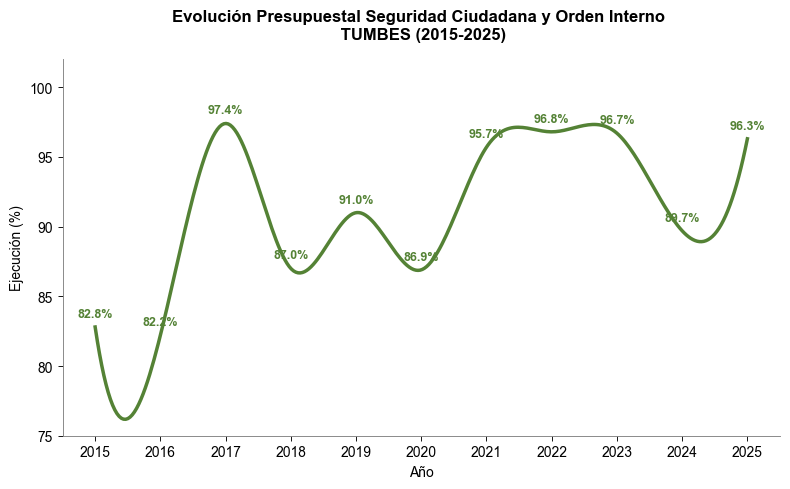

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.interpolate import make_interp_spline
import numpy as np
import os

# 1. Preparar datos y ruta ================================================
ruta_excel = r"C:\Users\edwar\OneDrive\Documents\reporte_ejecucion_mef_2015_2025.xlsx"

if os.path.exists(ruta_excel):
    # Cargamos el archivo Excel
    df_full = pd.read_excel(ruta_excel)
else:
    print(f"Error: No se encontró el archivo en {ruta_excel}")
    exit()

# Configuración de las regiones
regiones_config = {
    "CALLAO": {"nombre": "07: PROVINCIA CONSTITUCIONAL DEL CALLAO", "color": "#C00000"},
    "MADRE DE DIOS": {"nombre": "17: MADRE DE DIOS", "color": "#2E75B6"},
    "TUMBES": {"nombre": "24: TUMBES", "color": "#548235"}
}

# Configuración estética general
mpl.rcParams['font.family'] = 'Arial'

# 2. Bucle para generar 3 gráficos independientes =========================
for label, config in regiones_config.items():
    # Crear figura nueva para cada región
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Filtrar y ordenar datos
    df_reg = df_full[df_full["Región"] == config["nombre"]].dropna(subset=["Ejecución"]).sort_values("Año")
    x = df_reg["Año"].values
    y = df_reg["Ejecución"].values
    
    # Estilo de ejes minimalista
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    for s in ["left", "bottom"]:
        ax.spines[s].set_color("#808080")
        ax.spines[s].set_linewidth(0.64)
    ax.tick_params(axis="both", width=0.64, labelsize=10)

    # Suavizado de la línea (Spline)
    if len(x) > 3:
        x_smooth = np.linspace(x.min(), x.max(), 300)
        y_smooth = make_interp_spline(x, y, k=3)(x_smooth)
        ax.plot(x_smooth, y_smooth, color=config["color"], lw=2.5, label=f"Ejecución {label}")
    else:
        ax.plot(x, y, color=config["color"], lw=2.5, marker='o')

    # Etiquetas de datos sobre los puntos
    for xi, yi in zip(x, y):
        ax.text(xi, yi + 0.5, f"{yi:.1f}%", ha="center", va="bottom", 
                fontsize=9, color=config["color"], fontweight='bold')

    # Ajustes de ejes y títulos
    ax.set_ylim(75, 102) # Reescalado para mayor claridad
    ax.set_xticks(x)
    
    plt.title(f"Evolución Presupuestal Seguridad Ciudadana y Orden Interno \n {label} (2015-2025)", fontsize=12, fontweight='bold', pad=15)
    ax.set_ylabel("Ejecución (%)", fontsize=10)
    ax.set_xlabel("Año", fontsize=10)
    
    # Guardar cada gráfico por separado
    nombre_archivo = f"ejecucion_{label.lower().replace(' ', '_')}.png"
    output_img = os.path.join(os.path.dirname(ruta_excel), nombre_archivo)
    plt.tight_layout()
    plt.savefig(output_img, dpi=300, bbox_inches='tight')
    
    print(f"Gráfico de {label} guardado en: {output_img}")
    plt.show()
    